In [6]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import numpy as np

spark = SparkSession.builder.master("local[10]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("/home/h487/notebooks/jan2026/srppac/parquet/run1008_srppac_koji.parquet").select("id_x","timing_x","charge_x","id_y","timing_y","charge_y")
#df = spark.read.parquet("/home/h487/data/parquet/run1008.parquet")#.select("id_x","timing_x","charge_x","id_y","timing_y","charge_y")
df.show(5)

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|                id_x|            timing_x|            charge_x|                id_y|            timing_y|            charge_y|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|[15, 16, 14, 17, 13]|[-36.321005228041...|[41.1968220599956...|[15, 14, 16, 13, ...|[-36.524285553809...|[44.7078635575890...|
|[22, 23, 21, 24, 20]|[-35.204148576303...|[44.0444171784911...|    [11, 12, 10, 13]|[-36.283627525321...|[44.6355638009263...|
|[22, 23, 21, 24, 20]|[-35.412711190332...|[41.9068338023207...|[14, 15, 13, 16, 12]|[-36.211132141626...|[36.0924394435096...|
|[20, 19, 21, 18, 22]|[-35.096921119489...|[42.0163819625158...|[19, 20, 18, 21, 17]|[-36.234559944248...|[45.4004253261082...|
|[15, 16, 14, 17, 13]|[-36.451929519622...|[38.1966205434728...|[17, 18, 16, 19, 15]|[-35.271815837128..

Statistics:
[[0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 7.86982e+05 0.00000e+00]
 [0.00000e+00 1.80000e+01 0.00000e+00]]
Statistics:
[[0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 8.28262e+05 0.00000e+00]
 [0.00000e+00 3.90000e+01 0.00000e+00]]
Statistics:
[[     0.      0.      0.]
 [     0. 787000.      0.]
 [     0.      0.      0.]]
Statistics:
[[     0.      0.      0.]
 [     0. 828301.      0.]
 [     0.      0.      0.]]


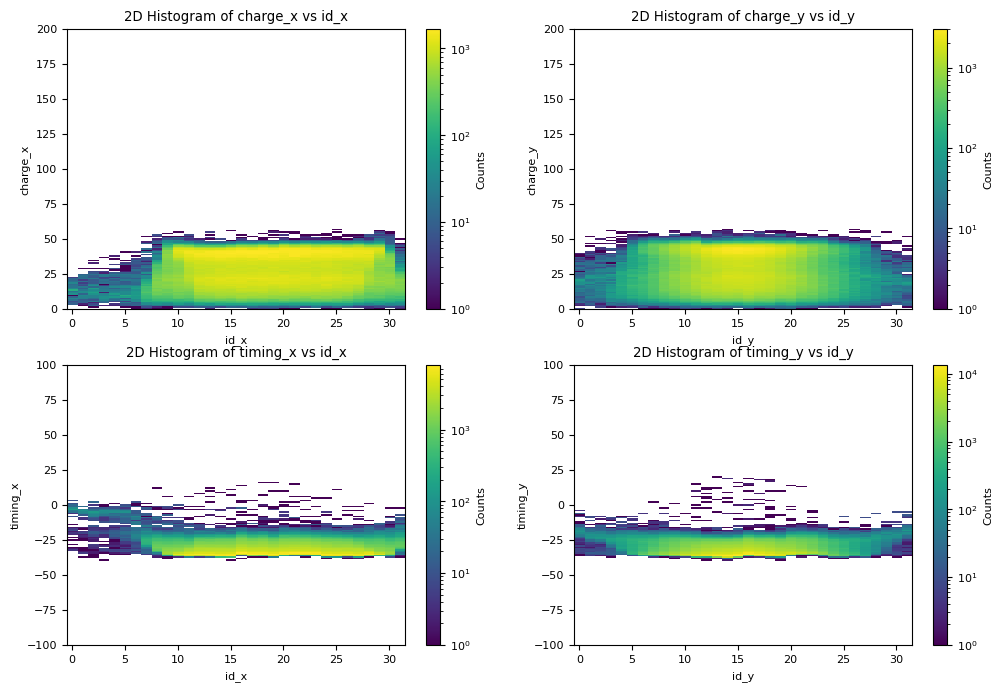

In [9]:
from hist.sparkHist2d import Hist2DArrays
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(0, figsize=(12,8))
plt.rcParams["font.size"] = 8
plt.subplot2grid((2,2),(0,0))
h = Hist2DArrays(df, ["id_x","charge_x"], [33,200], [[-0.5, 31.5], [0, 200]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,2),(0,1))
h = Hist2DArrays(df, ["id_y","charge_y"], [33,200], [[-0.5, 31.5], [0, 200]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,2),(1,0))
h = Hist2DArrays(df, ["id_x","timing_x"], [33,200], [[-0.5, 31.5], [-100, 100]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,2),(1,1))
h = Hist2DArrays(df, ["id_y","timing_y"], [33,200], [[-0.5, 31.5], [-100, 100]], norm=LogNorm(), interpolation='none')

plt.show()